<a href="https://colab.research.google.com/github/yugan243/Deep-Learning-Pytorch/blob/main/8_pytorch_datasets_and_dataloaders.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

sometimes processing data for neural networks can get messy and harder. and we need our data processing code decoupled from the model training code for better readability and modularity.
for processing data pytorch provides two premitives
*     torch.utils.data.Dataset
*     torch.utils.data.DataLoader

Dataset provides pre-loaded datasets and also it allows to load you own data too. And DataLoader wraps an iterable around **Dataset** for easy access.

We are using **FashionMNSIT** dataset from Dataset to explore the DataLoading


In [ ]:
import torch
from torch.utils.data import Dataset
from torchvision import datasets   # For vision based data
from torchvision.transforms import v2  # For image data transformations
import matplotlib.pyplot as plt


### Load the Dataset

In [ ]:
training_data = datasets.FashionMNIST(
    root="data",
    train=True,
    download=True,
    transform=v2.Compose([v2.ToImage(), v2.ToDtype(torch.float32, scale=True)])
)

test_data = datasets.FashionMNIST(
    root="data",
    train=False,
    download=True,
    transform=v2.Compose([v2.ToImage(), v2.ToDtype(torch.float32, scale=True)])
)

# PLTimage --> image tensor - pixel values 0-255  --> pytorch tensor 0.0 - 255.0  --> scale to 0-1

100%|██████████| 26.4M/26.4M [00:03<00:00, 8.74MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 154kB/s]
100%|██████████| 4.42M/4.42M [00:01<00:00, 2.69MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 9.01MB/s]


In [ ]:
training_data

Dataset FashionMNIST
    Number of datapoints: 60000
    Root location: data
    Split: Train
    StandardTransform
Transform: Compose(
                 ToImage()
                 ToDtype(scale=True)
           )

In [ ]:
print(f"train-size: {training_data.data.shape}")
print(f"sample train data: {training_data[0]}")

print(f"test-size: {test_data.data.shape}")
print(f"sample test data: {test_data[0]}")


train-size: torch.Size([60000, 28, 28])
sample train data: (Image([[[0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000],
        [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000],
        [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000],
        [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0039, 0.0000, 0.0000, 0.0510, 0.2863, 0.0

### Iterating and visualizing Dataset

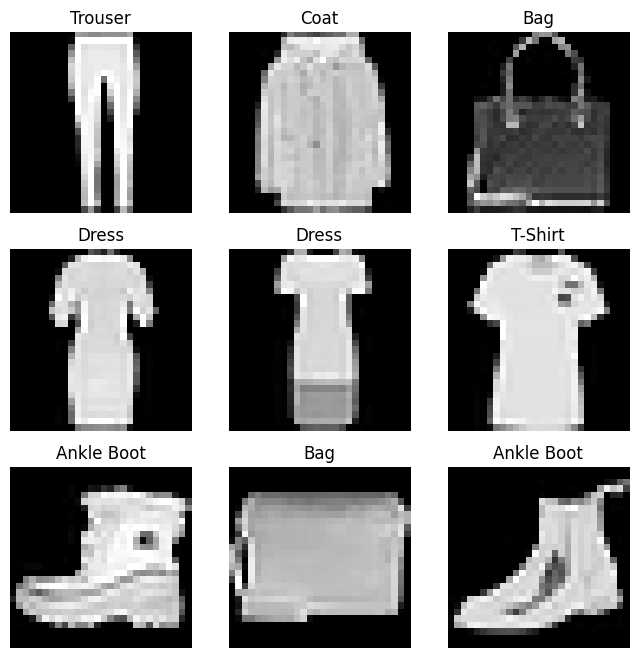

In [ ]:
labels_map = {
    0: "T-Shirt",
    1: "Trouser",
    2: "Pullover",
    3: "Dress",
    4: "Coat",
    5: "Sandal",
    6: "Shirt",
    7: "Sneaker",
    8: "Bag",
    9: "Ankle Boot",
}

figure = plt.figure(figsize=(8, 8))
cols, rows = 3, 3
for i in range(1, cols * rows + 1):
  sample_idx = torch.randint(len(training_data), size=(1,)).item()
  img, label = training_data[sample_idx]
  figure.add_subplot(rows, cols, i)
  plt.title(labels_map[label])
  plt.axis("off")
  plt.imshow(img.squeeze(), cmap="gray")  # img.shape is (1, 28, 28), matplotlib prefers the shape(28,28). so it squeezes any dimension with 1
plt.show()

In some cases our data could be stored separately in files as images in a one file and labels in another file. In these situations we need to create a Custom dataset using these files.

### Creating a Custom Dataset for your files ( Just in Case we have to work with)

When creating a class for a custom dataset, we need to inherit the base class **Dataset** and should implement all of its methods **_ _ _init_ _ _**, **_ _ _len_ _ _**, and **_ _ _get_item_ _ _**.

In [ ]:
import os
import pandas as pd
from torchvision.io import decode_image

In [ ]:
class CustomImageDataset(Dataset):
  def __init__(self, annotations_file, img_dir, transform=None, target_transform=None):
        self.img_labels = pd.read_csv(annotations_file)
        self.img_dir =img_dir
        self.transform = transform
        self.target_transform = target_transform

  def __len__(self):
        return len(self.img_labels)

  def __getitem__(self, idx):
        img_path = os.path.join(self.img_dir, self.img_labels.iloc[idx, 0])
        image = decode_image(img_path)
        label = self.img_labels.iloc[idx, 1]
        if self.transform:
            image = self.transform(image)
        if self.target_transform:
            label = self.target_transform(label)
        return image, label


### Preparing your data for training with DataLoaders

In [ ]:
from torch.utils.data import DataLoader

In [ ]:
train_dataloader = DataLoader(training_data, batch_size=64, shuffle=True)
test_dataloader = DataLoader(test_data, batch_size=63, shuffle=True)

Feature batch shape: torch.Size([64, 1, 28, 28])
Labels batch shape: torch.Size([64])


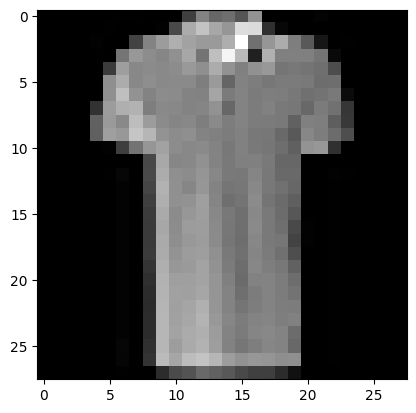

Label: 0


In [ ]:
# Iterate through the DataLoader
train_features, train_labels = next(iter(train_dataloader))
print(f"Feature batch shape: {train_features.shape}")
print(f"Labels batch shape: {train_labels.shape}")
img = train_features[0].squeeze()
label = train_labels[0]
plt.imshow(img, cmap="gray")
plt.show()
print(f"Label: {label}")